# Distance-threshold classification & plots for documentation

Dieses Notebook vereint die Logik aus:
- `dist_threshold_confusion_matrix_BAC_in_matrix_fixed.ipynb` (Merge + Threshold-Sweep/BAC)
- `visu_dist_pred_lesion_pred_needletip3.ipynb` (Plots: Histogramm/Boxplot/ROC/Confusion-Matrix + optional GT-vs-Pred)

Ziel: **ein durchlaufbarer, kohärenter Workflow** (oben → unten), der reproduzierbar die Plots erzeugt und optional als Dateien exportiert.


## 0) Setup & Konfiguration

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# -----------------------------
# Pfade (an deine Umgebung anpassen)
# -----------------------------
#DIST_CSV = Path("/home/students/studunals1/biopsy_project/x/test/voxelmorph/LOSS_axial_new_sweep/inf_260201_180928.csv")
DIST_CSV = Path("/home/students/studunals1/biopsy_project/x/data_augmentation/data_augmentation_1zu1.5/dist_pred_lesion_gt_needletip_test.csv")

# train = /home/students/studunals1/biopsy_project/x/train/voxelmorph/LOSS_axial_new_sweep/inf_260312_132214_train.csv
# val = /home/students/studunals1/biopsy_project/x/validation/voxelmorph/LOSS_axial_new_sweep/inf_260312_132214_val.csv
GT_LABEL_CSV = Path("/home/students/studunals1/biopsy_project/vxm/csv/Breast_MRI_Biopsy_anonym.csv")

# Optional: GT-Distanz-CSV (für Scatter + Bland-Altman)
# (nur nutzen, wenn vorhanden; sonst wird der Teil übersprungen)
GT_DIST_CSV = Path("/home/students/studunals1/biopsy_project/voxelmorph/notebooks_distances/dist_gt_lesion_gt_needletip.csv")

# Output-Ordner für Doku-Plots
PLOT_DIR = Path("./plots_doc")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Spaltennamen / Semantik
# -----------------------------
PRED_DIST_COL = "dist_pred_lesion_gt_needletip_mm"          # predicted lesion↔needle distance [mm]
GT_ID_COL     = "AnonymID"                             # ID in Label-CSV
GT_LABEL_COL  = "Repräsentative Biopsie Ja (0), Nein (1)"  # 0=repr, 1=non-repr (positiv)

# Klassifikations-Regel:
# pred=1 (non-repr) wenn dist > threshold
PRED_POSITIVE_IF = ">"  # ">" oder ">="

# Schwellen-/Auswertungsparameter
TARGET_BAC = 0.60

print("DIST_CSV:", DIST_CSV, "| exists:", DIST_CSV.exists())
print("GT_LABEL_CSV:", GT_LABEL_CSV, "| exists:", GT_LABEL_CSV.exists())
print("GT_DIST_CSV (optional):", GT_DIST_CSV, "| exists:", GT_DIST_CSV.exists())
print("PLOT_DIR:", PLOT_DIR.resolve())


DIST_CSV: /home/students/studunals1/biopsy_project/x/data_augmentation/data_augmentation_1zu1.5/dist_pred_lesion_gt_needletip_test.csv | exists: True
GT_LABEL_CSV: /home/students/studunals1/biopsy_project/vxm/csv/Breast_MRI_Biopsy_anonym.csv | exists: True
GT_DIST_CSV (optional): /home/students/studunals1/biopsy_project/voxelmorph/notebooks_distances/dist_gt_lesion_gt_needletip.csv | exists: True
PLOT_DIR: /mnt/ceph/vol_02_home_students/studunals1/biopsy_project/x/plots_doc


## 1) Utilities (robustes CSV-Lesen, Metriken, Plot-Helper)

In [19]:
def read_csv_robust(path: Path) -> pd.DataFrame:
    """Robustes Lesen bei unbekanntem Separator/Encoding."""
    seps = [",", ";", "\t", "|"]
    encodings = ["utf-8", "utf-8-sig", "cp1252", "latin1"]

    last_err = None
    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc)
                if df.shape[1] <= 1:
                    continue
                return df
            except Exception as e:
                last_err = e

    raise RuntimeError(f"CSV konnte nicht robust gelesen werden: {path}\nLetzter Fehler: {last_err}")

def to_str_series(s: pd.Series) -> pd.Series:
    """Sicheres Casting zu String (ohne .0 bei ints)."""
    return s.astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

def predict_from_threshold(d: np.ndarray, thr: float, rule: str = ">") -> np.ndarray:
    if rule == ">":
        return (d > thr).astype(int)
    if rule == ">=":
        return (d >= thr).astype(int)
    raise ValueError("rule must be '>' or '>='")

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    tpr = tp/(tp+fn) if (tp+fn) else np.nan  # Sensitivity
    tnr = tn/(tn+fp) if (tn+fp) else np.nan  # Specificity
    bac = 0.5*(tpr+tnr) if (np.isfinite(tpr) and np.isfinite(tnr)) else np.nan
    acc = (tp+tn)/ (tp+tn+fp+fn) if (tp+tn+fp+fn) else np.nan
    return {
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "TPR": float(tpr), "TNR": float(tnr),
        "BAC": float(bac), "ACC": float(acc)
    }

def savefig(fig, filename: str):
    out = PLOT_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print("Saved:", out)


## 2) Daten laden & mergen (Pred-Distanz + GT-Label)

In [20]:
# --- Distanz-Predictions laden ---
dist_df = read_csv_robust(DIST_CSV)
if "patient_id" not in dist_df.columns:
    raise KeyError(f"dist_df: patient_id nicht gefunden. Spalten: {list(dist_df.columns)}")
if PRED_DIST_COL not in dist_df.columns:
    raise KeyError(f"dist_df: {PRED_DIST_COL} nicht gefunden. Spalten: {list(dist_df.columns)}")

dist_df = dist_df.copy()
dist_df["patient_id"] = to_str_series(dist_df["patient_id"])
dist_df[PRED_DIST_COL] = pd.to_numeric(dist_df[PRED_DIST_COL], errors="coerce")

print("dist_df shape:", dist_df.shape)
display(dist_df.head())

# --- GT-Label laden ---
gt_df = read_csv_robust(GT_LABEL_CSV)
for c in [GT_ID_COL, GT_LABEL_COL]:
    if c not in gt_df.columns:
        raise KeyError(f"gt_df: Spalte '{c}' nicht gefunden. Spalten: {list(gt_df.columns)}")

gt_df = gt_df.copy()
gt_df[GT_ID_COL] = to_str_series(gt_df[GT_ID_COL])
gt_df[GT_LABEL_COL] = pd.to_numeric(gt_df[GT_LABEL_COL], errors="coerce")

# Doppelte IDs robust behandeln: pro ID ersten nicht-NaN Wert
tmp = gt_df[[GT_ID_COL, GT_LABEL_COL]].sort_values(GT_ID_COL)
gt_map = (tmp.groupby(GT_ID_COL)[GT_LABEL_COL]
            .apply(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)
            .reset_index()
            .rename(columns={GT_ID_COL: "patient_id", GT_LABEL_COL: "ground_truth"}))

merged = dist_df.merge(gt_map, on="patient_id", how="left")

print("merged shape:", merged.shape)
print("Missing ground_truth:", merged["ground_truth"].isna().sum(), "/", len(merged))
display(merged.head())

# Für die Auswertung: nur gültige GT + Distanz
df = merged.dropna(subset=[PRED_DIST_COL, "ground_truth"]).copy()
df["ground_truth"] = pd.to_numeric(df["ground_truth"], errors="coerce").astype(int)
df[PRED_DIST_COL] = pd.to_numeric(df[PRED_DIST_COL], errors="coerce")
df = df.dropna(subset=[PRED_DIST_COL]).copy()

y = df["ground_truth"].to_numpy()  # 0=repr, 1=non-repr (positiv)
x = df[PRED_DIST_COL].to_numpy()

print("N=", len(df), "| positives (1)=", int((y==1).sum()), "| negatives (0)=", int((y==0).sum()))


dist_df shape: (24, 4)


,patient_id,study_id,breast_side,dist_pred_lesion_gt_needletip_mm
0,10744914,20210927101351_20210927,rechts,13.407145
1,10781279,20200316104807_20200316,links,3.005924
2,25860874,20220223100806_20220223,links,7.180954
3,27167615,20200826090644_20200826,rechts,3.656590
4,29659453,20230612110607_20230612,rechts,16.865643


merged shape: (24, 5)
Missing ground_truth: 0 / 24


,patient_id,study_id,breast_side,dist_pred_lesion_gt_needletip_mm,ground_truth
0,10744914,20210927101351_20210927,rechts,13.407145,1.0
1,10781279,20200316104807_20200316,links,3.005924,0.0
2,25860874,20220223100806_20220223,links,7.180954,1.0
3,27167615,20200826090644_20200826,rechts,3.656590,0.0
4,29659453,20230612110607_20230612,rechts,16.865643,1.0


N= 24 | positives (1)= 10 | negatives (0)= 14


### Optional: merged CSV speichern (für späteres Re-Use)

## 3) Deskriptive Statistiken + Basis-Plots (Histogramm, Boxplot)

In [21]:
# Statistik-Tabelle (für Doku)
s = pd.to_numeric(df[PRED_DIST_COL], errors="coerce").dropna()

stats = pd.DataFrame({
    "Kennwert": [
        "n",
        "mean [mm]",
        "std [mm]",
        "min [mm]",
        "25% (Q1) [mm]",
        "median (50%) [mm]",
        "75% (Q3) [mm]",
        "max [mm]",
    ],
    "Wert": [
        int(s.shape[0]),
        float(s.mean()),
        float(s.std(ddof=1)),
        float(s.min()),
        float(s.quantile(0.25)),
        float(s.median()),
        float(s.quantile(0.75)),
        float(s.max()),
    ]
})
display(stats)


,Kennwert,Wert
0,n,24.000000
1,mean [mm],6.376391
2,std [mm],4.160990
3,min [mm],1.283089
4,25% (Q1) [mm],3.041710
5,median (50%) [mm],4.585750
6,75% (Q3) [mm],8.661624
7,max [mm],16.865643


Saved: plots_doc/hist_pred_distance_all.png


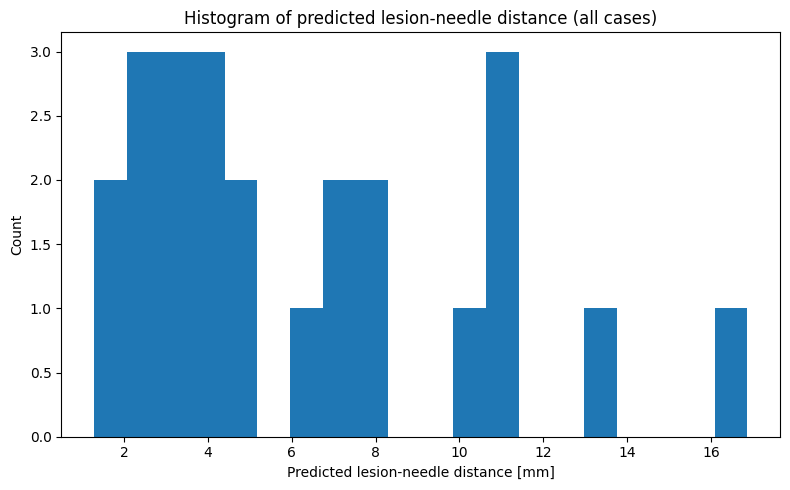

In [22]:
# Histogramm (alle Fälle)
fig = plt.figure(figsize=(8,5))
plt.hist(x, bins=20)
plt.title("Histogram of predicted lesion-needle distance (all cases)")
plt.xlabel("Predicted lesion-needle distance [mm]")
plt.ylabel("Count")
plt.tight_layout()
savefig(fig, "hist_pred_distance_all.png")
plt.show()


/tmp/ipykernel_676502/1054991263.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["GT=0 (repr)", "GT=1 (non-repr)"])


Saved: plots_doc/boxplot_pred_distance_by_gt.png


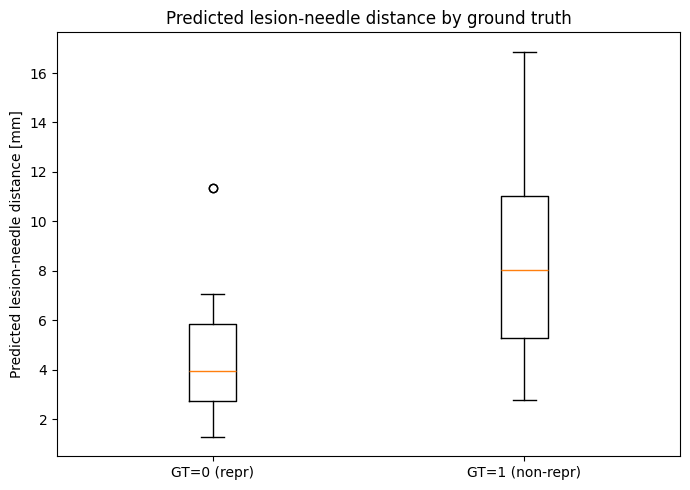

In [23]:
# Boxplot nach Ground Truth
data0 = df.loc[df["ground_truth"]==0, PRED_DIST_COL].to_numpy()
data1 = df.loc[df["ground_truth"]==1, PRED_DIST_COL].to_numpy()

fig = plt.figure(figsize=(7,5))
plt.boxplot([data0, data1], labels=["GT=0 (repr)", "GT=1 (non-repr)"])
plt.title("Predicted lesion-needle distance by ground truth")
plt.ylabel("Predicted lesion-needle distance [mm]")
plt.tight_layout()
savefig(fig, "boxplot_pred_distance_by_gt.png")
plt.show()


## 4) Threshold-Sweep (BAC) + Auswahl einer finalen Schwelle

In [24]:
# Kandidaten-Schwellen (Midpoints der unique Werte → deckt alle Sprünge ab)
u = np.unique(x[np.isfinite(x)])
u.sort()
thr_candidates = np.r_[u[0] - 1e-6, (u[:-1] + u[1:]) / 2.0, u[-1] + 1e-6] if len(u) else np.array([])

rows = []
for t in thr_candidates:
    yhat = predict_from_threshold(x, t, rule=PRED_POSITIVE_IF)
    m = compute_metrics(y, yhat)
    rows.append({
        "thr": float(t),
        **m
    })

results = pd.DataFrame(rows).sort_values("thr").reset_index(drop=True)
results["abs_err_to_target"] = (results["BAC"] - TARGET_BAC).abs()

display(results.head())
print("#threshold candidates:", len(results))


,thr,TP,TN,FP,FN,TPR,TNR,BAC,ACC,abs_err_to_target
0,1.283088,10,0,14,0,1.0,0.000000,0.500000,0.416667,0.100000
1,1.616914,10,1,13,0,1.0,0.071429,0.535714,0.458333,0.064286
2,2.257236,10,2,12,0,1.0,0.142857,0.571429,0.500000,0.028571
3,2.616067,10,3,11,0,1.0,0.214286,0.607143,0.541667,0.007143
4,2.718782,10,4,10,0,1.0,0.285714,0.642857,0.583333,0.042857


#threshold candidates: 25


Saved: plots_doc/bac_vs_threshold.png


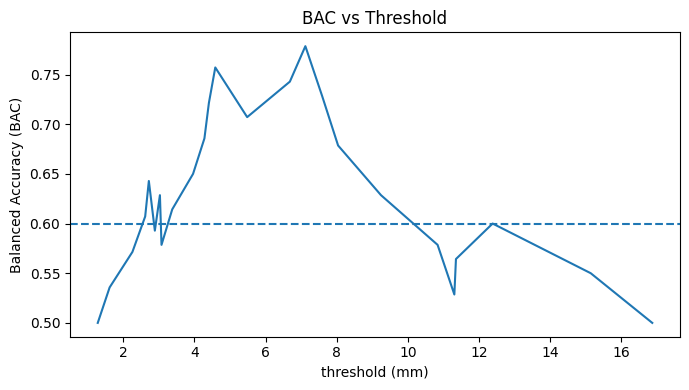

Best (max BAC): {'thr': 7.117305976335607, 'BAC': 0.7785714285714285, 'TPR': 0.7, 'TNR': 0.8571428571428571, 'TP': 7.0, 'TN': 12.0, 'FP': 2.0, 'FN': 3.0}
Best (closest to TARGET_BAC): {'thr': 12.379450881042107, 'BAC': 0.6, 'TPR': 0.2, 'TNR': 1.0, 'TP': 2.0, 'TN': 14.0, 'FP': 0.0, 'FN': 8.0}


In [25]:
# Plot: BAC vs threshold + Ziel-Linie
fig = plt.figure(figsize=(7,4))
plt.plot(results["thr"], results["BAC"])
plt.axhline(TARGET_BAC, linestyle="--")
plt.xlabel("threshold (mm)")
plt.ylabel("Balanced Accuracy (BAC)")
plt.title("BAC vs Threshold")
plt.tight_layout()
savefig(fig, "bac_vs_threshold.png")
plt.show()

# Vorschlag 1: maximale BAC
best_max = results.iloc[results["BAC"].idxmax()].to_dict()

# Vorschlag 2: BAC am nächsten an TARGET_BAC
best_target = results.iloc[results["abs_err_to_target"].idxmin()].to_dict()

print("Best (max BAC):", {k: best_max[k] for k in ["thr","BAC","TPR","TNR","TP","TN","FP","FN"]})
print("Best (closest to TARGET_BAC):", {k: best_target[k] for k in ["thr","BAC","TPR","TNR","TP","TN","FP","FN"]})


### Alternative Schwellen (wie im alten Visualisierungs-Notebook)

- **T1:** TP ≈ FN  
- **T2:** TP > FN und |TP−FN| minimal (falls möglich)  
- **T3:** TP maximal (Tie-break: höhere TNR)

Diese Auswahl ist optional – oft ist **max BAC** oder **target BAC** sinnvoller.


In [26]:
# T1 / T2 / T3 definieren
t1 = results.iloc[(results["TP"] - results["FN"]).abs().argsort()[:1]].iloc[0].to_dict()

cand = results[results["TP"] > results["FN"]].copy()
t2 = cand.iloc[(cand["TP"] - cand["FN"]).abs().argsort()[:1]].iloc[0].to_dict() if len(cand) else None

t3 = results.sort_values(["TP", "TNR"], ascending=[False, False]).iloc[0].to_dict()

print("T1:", {k: t1[k] for k in ["thr","BAC","TPR","TNR","TP","TN","FP","FN"]})
print("T2:", {k: t2[k] for k in ["thr","BAC","TPR","TNR","TP","TN","FP","FN"]} if t2 else None)
print("T3:", {k: t3[k] for k in ["thr","BAC","TPR","TNR","TP","TN","FP","FN"]})


T1: {'thr': 8.036881936312668, 'BAC': 0.6785714285714286, 'TPR': 0.5, 'TNR': 0.8571428571428571, 'TP': 5.0, 'TN': 12.0, 'FP': 2.0, 'FN': 5.0}
T2: {'thr': 7.586937954680343, 'BAC': 0.7285714285714285, 'TPR': 0.6, 'TNR': 0.8571428571428571, 'TP': 6.0, 'TN': 12.0, 'FP': 2.0, 'FN': 4.0}
T3: {'thr': 2.7187816221543617, 'BAC': 0.6428571428571428, 'TPR': 1.0, 'TNR': 0.2857142857142857, 'TP': 10.0, 'TN': 4.0, 'FP': 10.0, 'FN': 0.0}


### Finalen Threshold festlegen (hier: max BAC)

THR_FINAL = 7.117305976335607
Saved: plots_doc/hist_pred_distance_with_thr.png


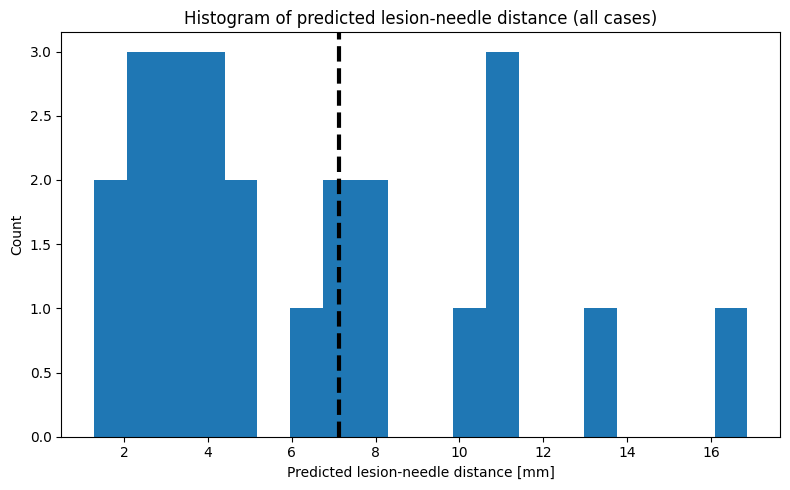

In [27]:
# Wähle hier, was du für deine Doku verwenden willst:
# THR_FINAL = float(best_target["thr"])
THR_FINAL = float(best_max["thr"])

print("THR_FINAL =", THR_FINAL)

# Histogramm + markierte Schwelle (für Doku)
fig = plt.figure(figsize=(8,5))
plt.hist(x, bins=20)
plt.axvline(THR_FINAL, linestyle="--", linewidth=3, color="black")
plt.title("Histogram of predicted lesion-needle distance (all cases)")
plt.xlabel("Predicted lesion-needle distance [mm]")
plt.ylabel("Count")
plt.tight_layout()
savefig(fig, "hist_pred_distance_with_thr.png")
plt.show()


## 5) Confusion Matrix für THR_FINAL

## 6) ROC-Kurve (AUC) + Schwellen-Markierungen

Saved: plots_doc/roc_auc.png


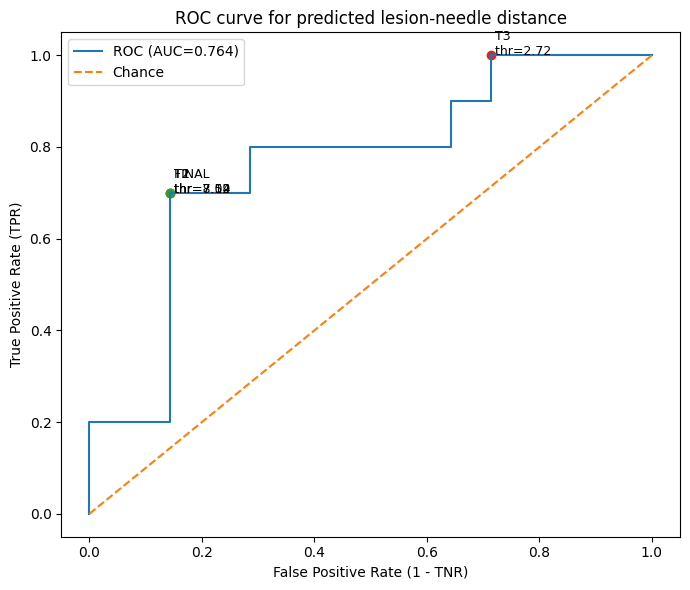

In [28]:
auc = roc_auc_score(y, x)
fpr, tpr, thr_roc = roc_curve(y, x)  # sklearn: größere Scores → positive Klasse (1)

fig = plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Chance")

def mark_threshold(thr_value, text):
    idx = int(np.argmin(np.abs(thr_roc - thr_value)))
    plt.scatter([fpr[idx]], [tpr[idx]])
    plt.text(fpr[idx], tpr[idx], f" {text}\n thr={thr_value:.2f}", fontsize=9)

mark_threshold(float(THR_FINAL), "FINAL")
mark_threshold(float(t1["thr"]), "T1")
if t2 is not None:
    mark_threshold(float(t2["thr"]), "T2")
mark_threshold(float(t3["thr"]), "T3")

plt.title("ROC curve for predicted lesion-needle distance")
plt.xlabel("False Positive Rate (1 - TNR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.tight_layout()
savefig(fig, "roc_auc.png")
plt.show()


## 7) Optional: Predicted distance vs. GT distance (Scatter + Bland-Altman)
Wird nur ausgeführt, wenn `GT_DIST_CSV` existiert und eine passende Spalte gefunden wird.

merged_dist shape: (23, 4)


,patient_id,dist_pred_lesion_gt_needletip_mm,ground_truth,gt_distance_lesion_neddletip
0,10744914,13.407145,1,14.964716
1,10781279,3.005924,0,3.921332
2,25860874,7.180954,1,8.175221
3,27167615,3.656590,0,0.900598
4,29659453,16.865643,1,22.223575


Saved: plots_doc/scatter_gt_vs_pred.png


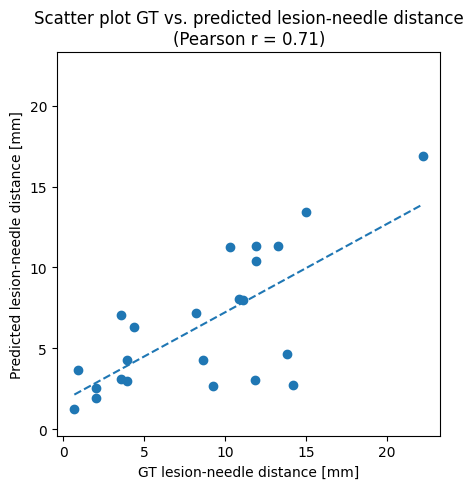

Saved: plots_doc/bland_altman.png


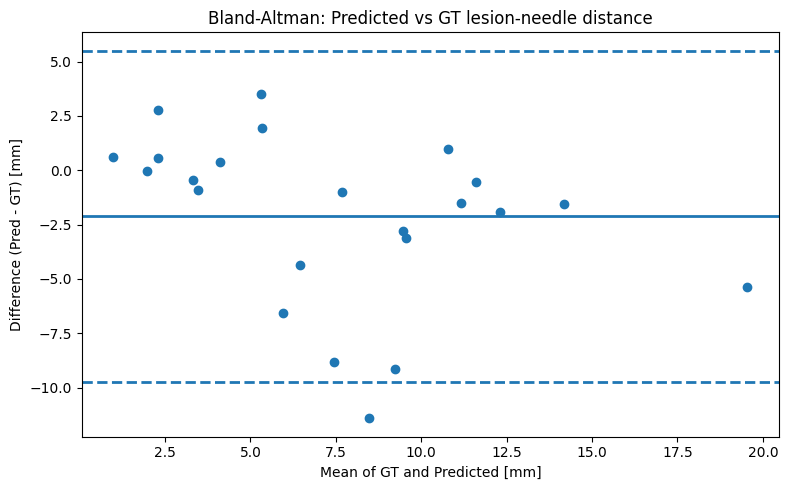

Mean diff (bias): -2.119 mm
LoA: [-9.739, 5.501] mm


In [29]:
if not GT_DIST_CSV.exists():
    print("GT_DIST_CSV nicht gefunden → Scatter/Bland-Altman wird übersprungen.")
else:
    pred = df[["patient_id", PRED_DIST_COL, "ground_truth"]].copy()
    gt = read_csv_robust(GT_DIST_CSV).copy()

    pred["patient_id"] = to_str_series(pred["patient_id"])
    gt["patient_id"] = to_str_series(gt["patient_id"])

    # mögliche GT-Spaltennamen (inkl. Tippfehler aus alten Dateien)
    gt_col_candidates = [
        "gt_distance_lesion_neddletip",
        "gt_distance_lesion_needletip",
        "gt_distance_lesion_neddletip ",
        "gt_distance_lesion_needletip ",
    ]
    gt_col = next((c for c in gt_col_candidates if c in gt.columns), None)
    if gt_col is None:
        raise ValueError(f"Keine GT-Distanz-Spalte gefunden. Vorhandene Spalten: {list(gt.columns)}")

    gt[gt_col] = pd.to_numeric(gt[gt_col], errors="coerce")
    pred[PRED_DIST_COL] = pd.to_numeric(pred[PRED_DIST_COL], errors="coerce")

    merged_dist = pred.merge(gt[["patient_id", gt_col]], on="patient_id", how="inner").dropna()
    print("merged_dist shape:", merged_dist.shape)
    display(merged_dist.head())

    x_gt = merged_dist[gt_col].to_numpy()
    y_pred = merged_dist[PRED_DIST_COL].to_numpy()

    # --- Scatter mit Regression + 1:1 Skalierung ---
    r = np.corrcoef(x_gt, y_pred)[0,1]
    a, b = np.polyfit(x_gt, y_pred, 1)
    xx = np.linspace(x_gt.min(), x_gt.max(), 200)
    yy = a*xx + b

    fig = plt.figure(figsize=(8,5))
    plt.scatter(x_gt, y_pred)
    plt.plot(xx, yy, linestyle="--")
    mn = min(x_gt.min(), y_pred.min())
    mx = max(x_gt.max(), y_pred.max())
    pad = 0.05*(mx-mn) if mx>mn else 1.0
    plt.xlim(mn-pad, mx+pad)
    plt.ylim(mn-pad, mx+pad)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Scatter plot GT vs. predicted lesion-needle distance\n(Pearson r = {r:.2f})")
    plt.xlabel("GT lesion-needle distance [mm]")
    plt.ylabel("Predicted lesion-needle distance [mm]")
    plt.tight_layout()
    savefig(fig, "scatter_gt_vs_pred.png")
    plt.show()

    # --- Bland-Altman ---
    mean = (x_gt + y_pred)/2
    diff = (y_pred - x_gt)

    md = float(np.mean(diff))
    sd = float(np.std(diff, ddof=1))
    loa_upper = md + 1.96*sd
    loa_lower = md - 1.96*sd

    fig = plt.figure(figsize=(8,5))
    plt.scatter(mean, diff)
    plt.axhline(md, linewidth=2)
    plt.axhline(loa_upper, linestyle="--", linewidth=2)
    plt.axhline(loa_lower, linestyle="--", linewidth=2)
    plt.title("Bland-Altman: Predicted vs GT lesion-needle distance")
    plt.xlabel("Mean of GT and Predicted [mm]")
    plt.ylabel("Difference (Pred - GT) [mm]")
    plt.tight_layout()
    savefig(fig, "bland_altman.png")
    plt.show()

    print(f"Mean diff (bias): {md:.3f} mm")
    print(f"LoA: [{loa_lower:.3f}, {loa_upper:.3f}] mm")


Saved: plots_doc/scatter_gt_vs_pred.png


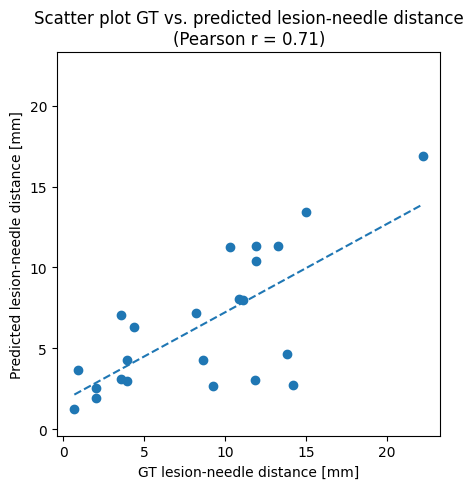

In [30]:
if not GT_DIST_CSV.exists():
    print("GT_DIST_CSV nicht gefunden → Scatter/Bland-Altman wird übersprungen.")
else:
    pred = df[["patient_id", PRED_DIST_COL, "ground_truth"]].copy()
    gt = read_csv_robust(GT_DIST_CSV).copy()

    pred["patient_id"] = to_str_series(pred["patient_id"])
    gt["patient_id"] = to_str_series(gt["patient_id"])

    # mögliche GT-Spaltennamen (inkl. Tippfehler aus alten Dateien)
    gt_col_candidates = [
        "gt_distance_lesion_neddletip",
        "gt_distance_lesion_needletip",
        "gt_distance_lesion_neddletip ",
        "gt_distance_lesion_needletip ",
    ]
    gt_col = next((c for c in gt_col_candidates if c in gt.columns), None)
    if gt_col is None:
        raise ValueError(f"Keine GT-Distanz-Spalte gefunden. Vorhandene Spalten: {list(gt.columns)}")

    gt[gt_col] = pd.to_numeric(gt[gt_col], errors="coerce")
    pred[PRED_DIST_COL] = pd.to_numeric(pred[PRED_DIST_COL], errors="coerce")

    merged_dist = pred.merge(gt[["patient_id", gt_col]], on="patient_id", how="inner").dropna()


    x_gt = merged_dist[gt_col].to_numpy()
    y_pred = merged_dist[PRED_DIST_COL].to_numpy()

    # --- Scatter mit Regression + 1:1 Skalierung ---
    r = np.corrcoef(x_gt, y_pred)[0,1]
    a, b = np.polyfit(x_gt, y_pred, 1)
    xx = np.linspace(x_gt.min(), x_gt.max(), 200)
    yy = a*xx + b

    fig = plt.figure(figsize=(8,5))
    plt.scatter(x_gt, y_pred)
    plt.plot(xx, yy, linestyle="--")
    mn = min(x_gt.min(), y_pred.min())
    mx = max(x_gt.max(), y_pred.max())
    pad = 0.05*(mx-mn) if mx>mn else 1.0
    plt.xlim(mn-pad, mx+pad)
    plt.ylim(mn-pad, mx+pad)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Scatter plot GT vs. predicted lesion-needle distance\n(Pearson r = {r:.2f})")
    plt.xlabel("GT lesion-needle distance [mm]")
    plt.ylabel("Predicted lesion-needle distance [mm]")
    plt.tight_layout()
    savefig(fig, "scatter_gt_vs_pred.png")
    plt.show()




Saved: plots_doc/scatter_gt_vs_pred_colored.png


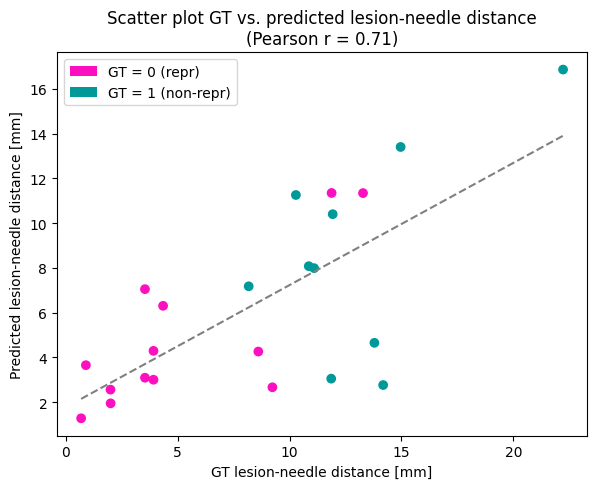

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Map ground truth to colors
colors = {0: "#FC0FC0", 1: "#009999"}  # 0=blue, 1=orange
point_colors = merged_dist["ground_truth"].map(colors)

# Compute correlation & regression
x_gt = merged_dist[gt_col].to_numpy()
y_pred = merged_dist[PRED_DIST_COL].to_numpy()
r = np.corrcoef(x_gt, y_pred)[0,1]
a, b = np.polyfit(x_gt, y_pred, 1)
xx = np.linspace(x_gt.min(), x_gt.max(), 200)
yy = a*xx + b

# Plot
fig = plt.figure(figsize=(8,5))
plt.scatter(x_gt, y_pred, c=point_colors, alpha=1.0)

plt.plot(xx, yy, linestyle="--", color="gray", label="Fit")
mn = min(x_gt.min(), y_pred.min())
mx = max(x_gt.max(), y_pred.max())
pad = 0.05*(mx-mn) if mx>mn else 1.0
plt.xlim(mn-pad, mx+pad)
#plt.ylim(mn-pad, mx+pad)
plt.gca().set_aspect("equal", adjustable="box")

plt.title(f"Scatter plot GT vs. predicted lesion-needle distance\n(Pearson r = {r:.2f})")
plt.xlabel("GT lesion-needle distance [mm]")
plt.ylabel("Predicted lesion-needle distance [mm]")

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FC0FC0", label="GT = 0 (repr)"),
    Patch(facecolor="#009999", label="GT = 1 (non-repr)")
]
plt.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
savefig(fig, "scatter_gt_vs_pred_colored.png")
plt.show()

Saved: plots_doc/boxplot_pred_distance_by_gt.png


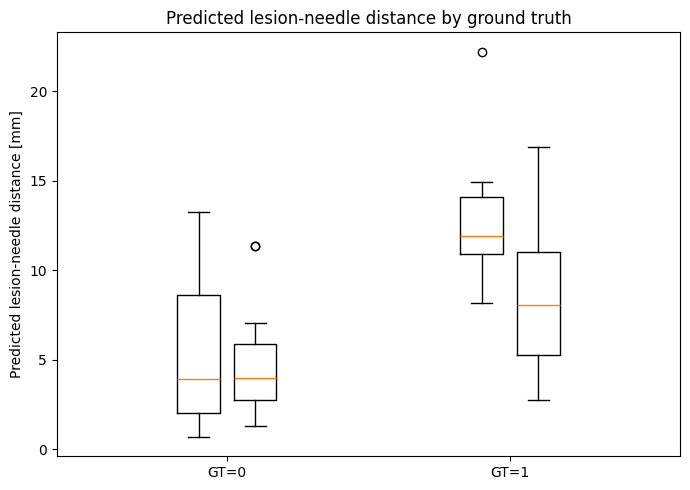

In [32]:
# Boxplot nach Ground Truth
PRED_DIST_COL = "dist_pred_lesion_gt_needletip_mm"
GT_COL = "gt_distance_lesion_neddletip"

data0 = df.loc[df["ground_truth"]==0, PRED_DIST_COL].to_numpy()
data1 = df.loc[df["ground_truth"]==1, PRED_DIST_COL].to_numpy()

dist_gt0 = merged_dist.loc[merged_dist["ground_truth"]==0, GT_COL].to_numpy()
dist_gt1 = merged_dist.loc[merged_dist["ground_truth"]==1, GT_COL].to_numpy()

fig = plt.figure(figsize=(7,5))


plt.boxplot([dist_gt0, data0], positions=[0.9, 1.1], widths=0.15)
plt.boxplot([dist_gt1, data1], positions=[1.9, 2.1], widths=0.15)

plt.xticks([1, 2], ["GT=0", "GT=1"])
plt.title("Predicted lesion-needle distance by ground truth")
plt.ylabel("Predicted lesion-needle distance [mm]")
plt.tight_layout()
savefig(fig, "boxplot_pred_distance_by_gt.png")
plt.show()

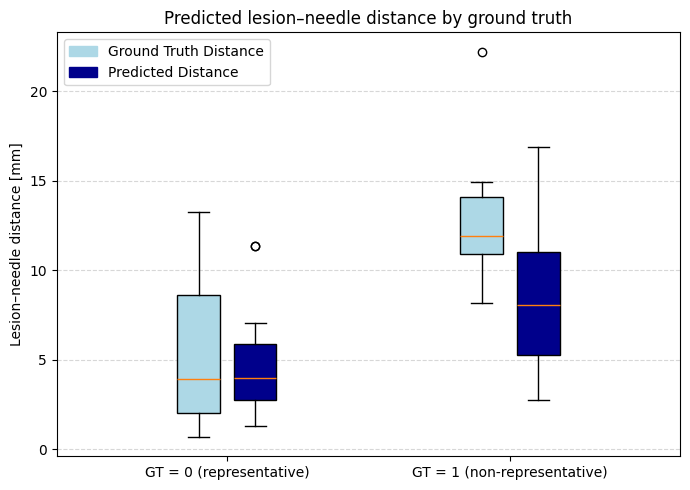

Mean: Pred 0: 4.81
Mean: GT 0:  5.22
Mean: Pred 1: 8.57
Mean: GT 1:  12.94
********************
Median: Pred 0: 3.96
Median: GT 0:  3.92
Median: Pred 1: 8.04
Median: GT 1:  11.9


In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7,5))

# Boxplots
bp1 = ax.boxplot([dist_gt0, data0],
                 positions=[0.9, 1.1],
                 widths=0.15,
                 patch_artist=True)

bp2 = ax.boxplot([dist_gt1, data1],
                 positions=[1.9, 2.1],
                 widths=0.15,
                 patch_artist=True)

# Colors
gt_color = "#4C72B0"     # blue
pred_color = "#DD8452"   # orange

bp1['boxes'][0].set_facecolor("lightblue")
bp1['boxes'][1].set_facecolor("darkblue")
bp2['boxes'][0].set_facecolor("lightblue")
bp2['boxes'][1].set_facecolor("darkblue")

# Styling
ax.set_xticks([1,2])
ax.set_xticklabels(["GT = 0 (representative)", "GT = 1 (non-representative)"])
ax.set_ylabel("Lesion–needle distance [mm]")
ax.set_title("Predicted lesion–needle distance by ground truth")

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

# Legend
legend_handles = [
    mpatches.Patch(color="lightblue", label="Ground Truth Distance"),
    mpatches.Patch(color="darkblue", label="Predicted Distance"),
]
ax.legend(handles=legend_handles)

plt.tight_layout()

plt.show()

print("Mean: Pred 0:", data0.mean().round(2))
print("Mean: GT 0: ", dist_gt0.mean().round(2))
print("Mean: Pred 1:", data1.mean().round(2))
print("Mean: GT 1: ", dist_gt1.mean().round(2))

print("*"*20)
print("Median: Pred 0:", np.median(data0).round(2))
print("Median: GT 0: ", np.median(dist_gt0).round(2))
print("Median: Pred 1:", np.median(data1).round(2))
print("Median: GT 1: ", np.median(dist_gt1).round(2))

In [34]:
!pip uninstall seaborn
y


array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0])

## 8) Kurzübersicht: Welche Dateien wurden exportiert?

In [35]:
# Liste exportierter Dateien
exports = sorted([p.name for p in PLOT_DIR.glob("*") if p.is_file()])
print("Exported plots:")
for f in exports:
    print(" -", f)


Exported plots:
 - bac_vs_threshold.png
 - bland_altman.png
 - boxplot_pred_distance_by_gt.png
 - confusion_matrix_final.png
 - hist_pred_distance_all.png
 - hist_pred_distance_with_thr.png
 - roc_auc.png
 - scatter_gt_vs_pred.png
 - scatter_gt_vs_pred_colored.png
